In [4]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset

df = pd.read_csv('/home/data.csv', sep=';')

print(df.shape)

# Step 3: Verify requirements for instructor approval
print(f"Dataset Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Step 4: Quick look at the data
df.head()

(4424, 37)
Dataset Rows: 4424, Columns: 37


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


/tmp/ipykernel_7965/1198873385.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Target', palette='Set2')


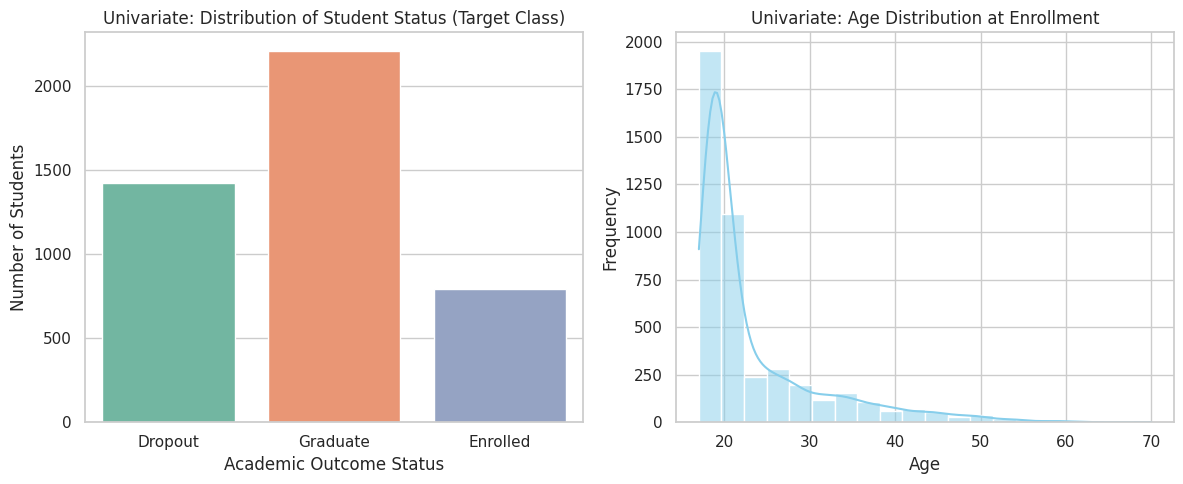

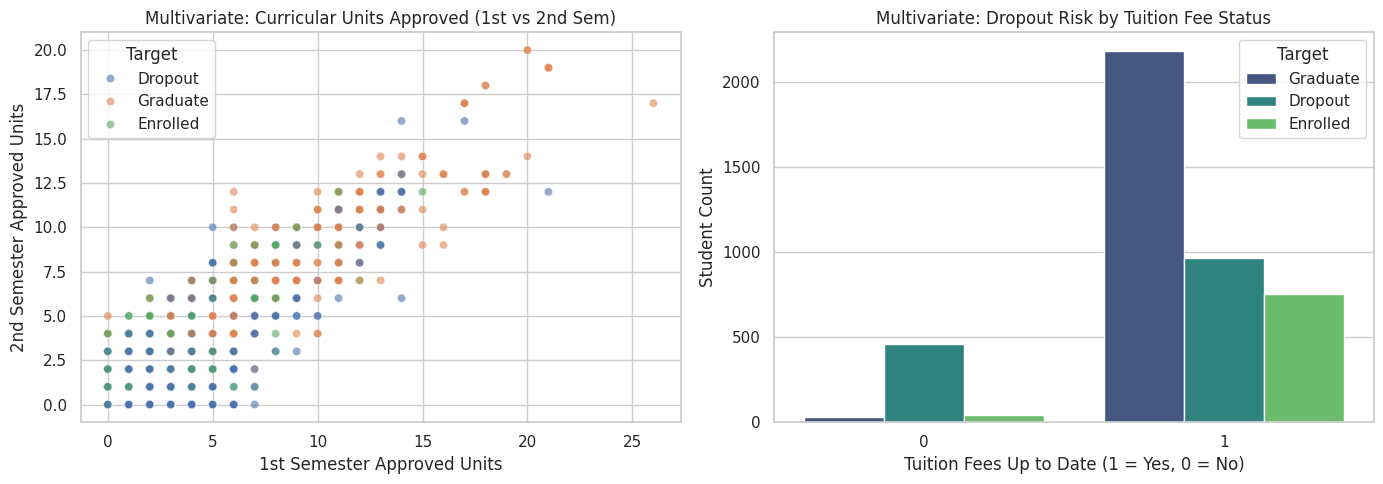

In [5]:
# 1. Install and import libraries
!pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# 2. Fetch the dataset
student_data = fetch_ucirepo(id=697)
X = student_data.data.features
y = student_data.data.targets

# Combine into a single dataframe for visualization ease
df = X.copy()
df['Target'] = y['Target']

# Set style for professional plots
sns.set_theme(style="whitegrid")

# --- UNIVARIATE VISUALIZATIONS ---
plt.figure(figsize=(12, 5))

# Plot 1: Distribution of Target Class
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Target', palette='Set2')
plt.title('Univariate: Distribution of Student Status (Target Class)')
plt.xlabel('Academic Outcome Status')
plt.ylabel('Number of Students')

# Plot 2: Distribution of Age at Enrollment
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='Age at enrollment', bins=20, kde=True, color='skyblue')
plt.title('Univariate: Age Distribution at Enrollment')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# --- MULTIVARIATE VISUALIZATIONS ---
plt.figure(figsize=(14, 5))

# Plot 3: 1st Sem Approved Units vs 2nd Sem Approved Units colored by Target
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Curricular units 1st sem (approved)',
                y='Curricular units 2nd sem (approved)', hue='Target', alpha=0.6)
plt.title('Multivariate: Curricular Units Approved (1st vs 2nd Sem)')
plt.xlabel('1st Semester Approved Units')
plt.ylabel('2nd Semester Approved Units')

# Plot 4: Tuition Fees Status vs Target Status
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Tuition fees up to date', hue='Target', palette='viridis')
plt.title('Multivariate: Dropout Risk by Tuition Fee Status')
plt.xlabel('Tuition Fees Up to Date (1 = Yes, 0 = No)')
plt.ylabel('Student Count')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# 1. Data Cleaning & Preparation
# Map target into binary classification (1 = Dropout, 0 = Stayed/Graduated)
df_ml = df.copy()
df_ml['Target'] = df_ml['Target'].map({'Dropout': 1, 'Graduate': 0, 'Enrolled': 0})

X_clean = df_ml.drop('Target', axis=1)
y_clean = df_ml['Target']

# Train-Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

# Feature Scaling (Crucial for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Classical ML Model: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# 3. Deep Learning Model: Neural Network (MLP)
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn_model.fit(X_train_scaled, y_train)
nn_preds = nn_model.predict(X_test_scaled)
nn_probs = nn_model.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluation Metrics
print("=== CLASSICAL ML: RANDOM FOREST PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")
print(classification_report(y_test, rf_preds))

print("\n=== NEURAL NETWORK PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, nn_preds):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, nn_probs):.4f}")
print(classification_report(y_test, nn_preds))

=== CLASSICAL ML: RANDOM FOREST PERFORMANCE ===
Accuracy: 0.8847
ROC-AUC: 0.9295
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       601
           1       0.89      0.73      0.80       284

    accuracy                           0.88       885
   macro avg       0.89      0.84      0.86       885
weighted avg       0.89      0.88      0.88       885


=== NEURAL NETWORK PERFORMANCE ===
Accuracy: 0.8395
ROC-AUC: 0.8805
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       601
           1       0.76      0.72      0.74       284

    accuracy                           0.84       885
   macro avg       0.82      0.81      0.81       885
weighted avg       0.84      0.84      0.84       885



In [8]:
!pip install gradio
import gradio as gr

def predict_student_risk(age, gender, tuition_status, sem1_approved, sem2_approved):
    # Map raw user inputs back to dataframe structure format
    # Initializing a blank baseline row matching our training structure
    input_row = np.zeros(X_clean.shape[1])

    # Locate specific feature index positions to update with inputs
    feature_list = list(X_clean.columns)
    input_row[feature_list.index('Age at enrollment')] = age
    input_row[feature_list.index('Gender')] = 1 if gender == "Male" else 0
    input_row[feature_list.index('Tuition fees up to date')] = 1 if tuition_status == "Up to Date" else 0
    input_row[feature_list.index('Curricular units 1st sem (approved)')] = sem1_approved
    input_row[feature_list.index('Curricular units 2nd sem (approved)')] = sem2_approved

    # Reshape and scale the array input
    scaled_input = scaler.transform([input_row])

    # Get probability output from the Random Forest model
    dropout_prob = rf_model.predict_proba(scaled_input)[0][1]

    status = "⚠️ HIGH RISK OF DROPOUT" if dropout_prob > 0.50 else "✅ LOW RISK / SUCCESS"
    return f"Prediction: {status}\nCalculated Dropout Probability: {dropout_prob*100:.2f}%"

# Create Gradio UI elements
interface = gr.Interface(
    fn=predict_student_risk,
    inputs=[
        gr.Slider(17, 60, step=1, label="Age at Enrollment"),
        gr.Radio(["Female", "Male"], label="Gender"),
        gr.Radio(["Up to Date", "Overdue / Debtor"], label="Tuition Fee Status"),
        gr.Number(label="1st Semester Approved Curricular Units", value=5),
        gr.Number(label="2nd Semester Approved Curricular Units", value=5)
    ],
    outputs=gr.Textbox(label="Model Predictive Output Assessment"),
    title="Student Retention Analytics Interface Platform",
    description="Input dynamic student attributes below to query the trained Random Forest model backend for attrition calculations."
)

# Launch the live service directly from Colab
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff915527a007a09e32.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
